In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

In [2]:
EBC = pd.read_csv('equal_beta_portfolio_return.csv', index_col=0)
EBC.columns = ["EBC"]
EBC.index = pd.to_datetime(EBC.index)
EBC

,EBC
date,
1967-01-01,0.105809
1967-02-01,0.007303
1967-03-01,0.043577
1967-04-01,0.032736
1967-05-01,-0.027935
...,...
2024-08-01,0.030202
2024-09-01,0.016253
2024-10-01,-0.016896


In [3]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)

# Keep only rows with YYYYMM format
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]

# Convert index to period-end timestamps (e.g., '202401' -> '2024-01-31')
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m").to_period("M").to_timestamp("M")

# Convert all factor values to numeric and scale to decimal
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100

ff_df.index = pd.to_datetime(ff_df.index).to_period('M').start_time

ff_df = ff_df.loc[EBC.index]

ff_df = ff_df["RF"]
ff_df

date
1967-01-01    0.0043
1967-02-01    0.0036
1967-03-01    0.0039
1967-04-01    0.0032
1967-05-01    0.0033
               ...  
2024-08-01    0.0048
2024-09-01    0.0040
2024-10-01    0.0039
2024-11-01    0.0040
2024-12-01    0.0037
Name: RF, Length: 696, dtype: float64

In [4]:
Cap_EBC = pd.read_csv('spread.csv', index_col=0)
Cap_EBC.index = pd.to_datetime(Cap_EBC.index)
Cap_EBC

,Spread Return
date,
1967-01-01,-0.022394
1967-02-01,0.002736
1967-03-01,0.000430
1967-04-01,0.014722
1967-05-01,-0.016680
...,...
2024-08-01,-0.002086
2024-09-01,0.009603
2024-10-01,0.012110


In [5]:
sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time
sp500 = sp_500.loc[Cap_EBC.index]
sp500

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-01,0.140523,0.145374,0.146104,NaN,0.105364,NaN,NaN,NaN,-0.045045,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-01,-0.036103,-0.015385,-0.019830,NaN,0.029463,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-03-01,0.156627,0.020313,0.102339,NaN,0.112245,NaN,NaN,NaN,-0.035849,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-04-01,0.052083,0.007752,0.018568,NaN,0.039755,NaN,NaN,NaN,0.079208,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-05-01,-0.018812,-0.023077,-0.072917,NaN,-0.064706,NaN,NaN,NaN,-0.108257,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-01,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-01,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025


In [6]:
rf = ff_df.reindex(EBC.index)

EBC = EBC.subtract(rf, axis=0)
Cap_EBC = Cap_EBC.subtract(rf, axis=0)
sp500 = sp500.subtract(rf, axis=0)
EBC


,EBC
date,
1967-01-01,0.101509
1967-02-01,0.003703
1967-03-01,0.039677
1967-04-01,0.029536
1967-05-01,-0.031235
...,...
2024-08-01,0.025402
2024-09-01,0.012253
2024-10-01,-0.020796


<Axes: xlabel='date'>

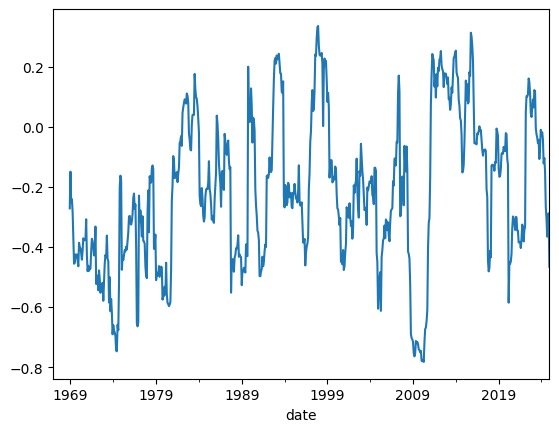

In [7]:
corr = EBC["EBC"].rolling(window=24).corr(Cap_EBC["Spread Return"])
corr.plot()

<Axes: xlabel='date'>

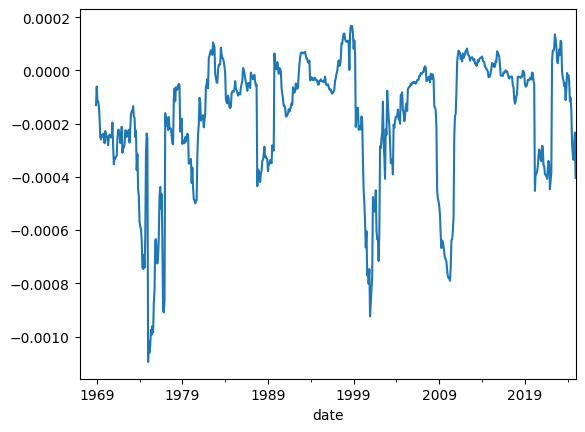

In [8]:
cov = EBC["EBC"].rolling(window=24).cov(Cap_EBC["Spread Return"])
cov.plot()

In [9]:
def compute_betas(sp500, factor_returns, ROLLING_WINDOW=36, MIN_OBS=10):
    """2 pass multi factor Fama-MacBeth"""

    asset_cols = sp500.columns
    combined = sp500.join(factor_returns, how="inner")

    # Prepare betas containers as float from the start
    betas_dict = {
        f: pd.DataFrame(index=pd.Index([], name="date"), columns=asset_cols, dtype=float)
        for f in factor_returns.columns
    }
    beta_dates = []

    # ---------- First pass: rolling time-series ----------
    for end_date in tqdm(combined.index[ROLLING_WINDOW-1:-1], desc="Time-series betas"):
        pos = combined.index.get_loc(end_date)
        next_date = combined.index[pos + 1]

        start_idx = pos - (ROLLING_WINDOW - 1)
        window_dates = combined.index[start_idx: start_idx + ROLLING_WINDOW]

        # Build window, drop any rows where either y or X has NaN
        x_win = factor_returns.loc[window_dates]
        for asset in asset_cols:
            y_win = sp500.loc[window_dates, asset]
            data = pd.concat([y_win, x_win], axis=1).dropna()
            if len(data) < MIN_OBS:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            Y = pd.to_numeric(data[asset], errors="coerce").astype(float)
            X = sm.add_constant(
                data[factor_returns.columns].apply(pd.to_numeric, errors="coerce").astype(float),
                has_constant="add"
            )

            # Guard against singular matrix if too few distinct X rows
            if X.shape[0] <= X.shape[1] or np.linalg.matrix_rank(X) < X.shape[1]:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            res = sm.OLS(Y, X).fit()

            for f in factor_returns.columns:
                betas_dict[f].loc[next_date, asset] = res.params.get(f, np.nan)

        beta_dates.append(next_date)

    return betas_dict

In [10]:
betas_EBC = compute_betas(sp500, EBC, 36, 10)
betas_Cap_EBC = compute_betas(sp500, Cap_EBC, 36, 10)

Time-series betas: 100%|██████████| 660/660 [10:21<00:00,  1.06it/s]


In [11]:
Betas_EBC = betas_EBC["EBC"]
# Betas_EBC = Betas_EBC[:400]
dic = {"EBC": Betas_EBC}
dic

{'EBC':                  ACF       ABK       AMT  JAVA        AN      ORCL      MSFT  \
 date                                                                           
 1970-01-01  1.333162  1.499542  0.510353   NaN  1.165416       NaN       NaN   
 1970-02-01  1.327381  1.527215  0.402780   NaN  1.034648       NaN       NaN   
 1970-03-01  1.290869  1.515709  0.349719   NaN  0.991152       NaN       NaN   
 1970-04-01  1.226908  1.561163  0.290040   NaN  0.949461       NaN       NaN   
 1970-05-01  1.165779  1.588972  0.309336   NaN  0.936422       NaN       NaN   
 ...              ...       ...       ...   ...       ...       ...       ...   
 2024-08-01       NaN       NaN       NaN   NaN       NaN  1.179202  0.779066   
 2024-09-01       NaN       NaN       NaN   NaN       NaN  1.173630  0.763392   
 2024-10-01       NaN       NaN       NaN   NaN       NaN  1.198837  0.740915   
 2024-11-01       NaN       NaN       NaN   NaN       NaN  1.182902  0.686763   
 2024-12-01       NaN

In [12]:
Betas_Cap_EBC = betas_Cap_EBC["Spread Return"]
# Betas_Cap_EBC = Betas_Cap_EBC[:400]
dic2 = {"Spread Return": Betas_Cap_EBC}

In [13]:
# Two-way sort -> equal-weight portfolios -> TS regressions -> Fama-MacBeth
# Assumes:
# - sp500 : DataFrame of asset returns (index dates), columns = tickers
# - betas_EBC: dict returned by compute_betas, e.g. {'EBC': DataFrame(dates x tickers)}
# - betas_Cap_EBC: dict returned by compute_betas for the second factor (spread)
# - factor series (EBC, Cap_EBC) are available as DataFrames EBC and Cap_EBC used earlier

# PARAMETERS
n_q1 = 3
n_q2 = 3
min_assets_per_cell = 3  #require at least this many assets to compute a portfolio return

# pick factor names (from your betas dicts)
f1_name = list(betas_EBC.keys())[0]
f2_name = list(betas_Cap_EBC.keys())[0]

# intersect dates where both beta matrices have rows and sp500 has returns
dates1 = dic[f1_name].index
dates2 = dic2[f2_name].index
dates_common = dates1.intersection(dates2).intersection(sp500.index)

# container for portfolio returns (equal-weighted)
port_ret_rows = []

print(f"Using factor names: f1={f1_name}, f2={f2_name}")
print(f"Number of rebalance dates: {len(dates_common)}")

for date in tqdm(sorted(dates_common), desc="forming portfolios"):
    try:
        beta1 = dic[f1_name].loc[date]   # Series indexed by asset
        beta2 = dic2[f2_name].loc[date]
    except KeyError:
        # skip if a factor missing for this date
        continue

    # returns at the same date (matching compute_betas design)
    if date not in sp500.index:
        continue
    ret_t = sp500.loc[date]

    df = pd.DataFrame({
        'beta1': beta1,
        'beta2': beta2,
        'ret': ret_t
    })

    df = df.dropna(subset=['beta1', 'beta2', 'ret'])
    if df.shape[0] == 0:
        continue

    # create quantiles robustly: try qcut, but fallback to rank-based if qcut fails
    def assign_q(series, nq):
        try:
            q = pd.qcut(series, nq, labels=False) + 1
        except Exception:
            # fallback: rank / quantiles
            ranks = series.rank(method='first')
            q = pd.cut(ranks, bins=nq, labels=False) + 1
        return nq + 1 - q

    df['q1'] = assign_q(df['beta1'], n_q1)
    print(df["q1"])
    # df['q2'] = assign_q(df['beta2'], n_q2)

    df['q2'] = np.nan

    # assign Q2 inside each Q1 group
    for i in range(1, n_q1 + 1):
        mask = df['q1'] == i
        if mask.sum() > 0:
            df.loc[mask, 'q2'] = assign_q(df.loc[mask, 'beta2'], n_q2)

    df['q2'] = df['q2'].astype(int)

    if 'quantile_map' not in locals():
        quantile_map = []
    for i in range(1, n_q1 + 1):
        for j in range(1, n_q2 + 1):
            stocks_in_cell = df.index[(df['q1'] == i) & (df['q2'] == j)].tolist()
            quantile_map.append({'date': date, 'q1': i, 'q2': j, 'stocks': stocks_in_cell})

    # compute equal-weighted return for each cell
    for i in range(1, n_q1+1):
        for j in range(1, n_q2+1):
            cell = df[(df['q1'] == i) & (df['q2'] == j)]
            if cell.shape[0] < min_assets_per_cell:
                # not enough assets -> nan (keeps panel consistent)
                ret_ew = np.nan
                n_assets = cell.shape[0]
            else:
                ret_ew = cell['ret'].mean()
                n_assets = cell.shape[0]

            port_ret_rows.append({
                'date': date,
                'q1': i,
                'q2': j,
                'ret_ew': ret_ew,
                'n_assets': n_assets
            })

# build DataFrame of portfolio returns
portrets = pd.DataFrame(port_ret_rows)

if 'quantile_map' in locals():
    quantile_map_df = pd.DataFrame(quantile_map)
    quantile_map_df.set_index(['date', 'q1', 'q2'], inplace=True)
    print("\nQuantile membership table created:")
    print(quantile_map_df.head())
else:
    print("No quantile_map found — make sure code inside loop ran correctly.")
portrets['date'] = pd.to_datetime(portrets['date'])
portrets = portrets.set_index(['date', 'q1', 'q2']).sort_index()

# Pivot to wide: columns are portfolio labels like "q1_q2" (useful for regressions)
portrets_wide = portrets['ret_ew'].unstack(level=[1,2])  # columns MultiIndex (q1,q2)
# flatten cols to strings
portrets_wide.columns = [f"Q{c[0]}_Q{c[1]}" for c in portrets_wide.columns]
portrets_wide = portrets_wide.sort_index(axis=1)

print("\nPortfolio panel shape (dates x portfolios):", portrets_wide.shape)
print("Example columns:", portrets_wide.columns[:8].tolist())
print(portrets_wide.head(100))

# ============================
# 1) Time-series regressions per portfolio (TS betas, alphas)
# ============================
# prepare factor returns series aligned to the portfolio index
# factor DataFrames EBC and Cap_EBC already exist in your workspace; ensure they align
factors = pd.concat([EBC, Cap_EBC], axis=1).dropna()
factors = factors.loc[portrets_wide.index.intersection(factors.index)]
portrets_wide = portrets_wide.loc[portrets_wide.index.intersection(factors.index)]

# ensure same date order
factors = factors.loc[portrets_wide.index]

ts_res = {}   # store regression results per portfolio
for port in portrets_wide.columns:
    y = portrets_wide[port].dropna()
    if len(y) < 12:
        # skip portfolios with too few observations
        ts_res[port] = None
        continue
    X = factors.loc[y.index]
    Xc = sm.add_constant(X, has_constant='add')
    try:
        model = sm.OLS(y, Xc).fit()
    except Exception as e:
        ts_res[port] = None
        continue

    ts_res[port] = {
        'alpha': model.params['const'],
        'alpha_t': model.tvalues['const'],
        'betaEBC': model.params.get(f1_name, np.nan),
        'betaCap_EBC': model.params.get(f2_name, np.nan),
        'betaEBC_t': model.tvalues.get(f1_name, np.nan),
        'betaCap_EBC_t': model.tvalues.get(f2_name, np.nan),
        'rsq': model.rsquared,
        'nobs': int(model.nobs)
    }

# TS results DataFrame
ts_summary = pd.DataFrame.from_dict(ts_res, orient='index')
print("\nTime-series regressions summary:")
print(ts_summary.dropna().head(25))

# ============================
# 2) Fama-MacBeth across portfolios
#    - Step A: get portfolio betas (we use the TS full-sample betas estimated above)
#    - Step B: for each date t, run cross-sectional regression: R_pt = gamma0_t + gamma1_t * beta1_p + gamma2_t * beta2_p + e_pt
#    - Step C: average gamma_t across time, compute t-stats
# ============================

# collect portfolio-level betas (from ts_summary)
beta_table = ts_summary[['betaEBC', 'betaCap_EBC']].copy()
beta_table = beta_table.dropna()
print("aaaaa")
print(beta_table.head(25))

# Align portfolio returns to the set of portfolios for which we have betas
valid_ports = beta_table.index.tolist()
R_panel = portrets_wide[valid_ports].copy()

# make sure index order consistent with factors
R_panel = R_panel.loc[factors.index.intersection(R_panel.index)]
print("aaaaa")
print(R_panel)
factors = factors.loc[R_panel.index]
print("aaaaa")
print(factors)

# At each date, run the cross-section
gamma_rows = []
cs_nobs = 0
for date, row in R_panel.iterrows():
    R_t = row.dropna()
    if R_t.shape[0] < 3:
        gamma_rows.append({'date': date, 'alpha': np.nan, 'lambdaEBC': np.nan, 'lambda_Cap_EBC': np.nan})
        continue

    # the betas are time-invariant here (portfolio-level)
    beta_mat = beta_table.loc[R_t.index]  # rows = portfolios in cross-section
    X_cs = sm.add_constant(beta_mat)
    try:
        res_cs = sm.OLS(R_t.values, X_cs.values).fit()
        params = res_cs.params
        gamma_rows.append({'date': date, 'alpha': params[0], 'lambdaEBC': params[1], 'lambda_Cap_EBC': params[2]})
        cs_nobs += 1
    except Exception:
        gamma_rows.append({'date': date, 'alpha': np.nan, 'lambdaEBC': np.nan, 'lambda_Cap_EBC': np.nan})

gammas = pd.DataFrame(gamma_rows).set_index('date')
print("aaaaa")
print(gammas)

# drop missing
gammas = gammas.dropna()

# FM estimates: mean of gamma_t and t-stat = mean(gamma)/ (std(gamma)/sqrt(T))
T_eff = gammas.shape[0]
fm_mean = gammas.mean()
fm_se = gammas.std(ddof=1) / np.sqrt(T_eff)
fm_tstats = fm_mean / fm_se

fm_table = pd.DataFrame({
    'lambda_mean': fm_mean,
    'lambda_se': fm_se,
    'lambda_fm_tstat': fm_tstats
})
print("\nFama-MacBeth results (factor premia):")
print(fm_table)

# ============================
# 3) Pricing errors (alphas) under FM prices
#    For each portfolio p: alpha_FM_p = mean(R_p) - (beta_p1 * gamma1_mean + beta_p2 * gamma2_mean + gamma0_mean)
#    Also present TS regression alpha for comparison
# ============================
gamma0_bar = fm_table.loc['alpha', 'lambda_mean']
gamma1_bar = fm_table.loc['lambdaEBC', 'lambda_mean']
gamma2_bar = fm_table.loc['lambda_Cap_EBC', 'lambda_mean']

portfolio_mean_returns = R_panel.mean()
pricing_errors = []
for p in valid_ports:
    mean_r = portfolio_mean_returns[p]
    b1 = beta_table.loc[p, 'betaEBC']
    b2 = beta_table.loc[p, 'betaCap_EBC']
    alpha_fm = mean_r - (gamma0_bar + gamma1_bar * b1 + gamma2_bar * b2)
    ts_alpha = ts_summary.loc[p, 'alpha'] if p in ts_summary.index else np.nan
    pricing_errors.append({
        'portfolio': p,
        'mean_return': mean_r,
        'betaEBC': b1,
        'betaCap_EBC': b2,
        'alpha_ts': ts_alpha,
        'alpha_fm': alpha_fm
    })

pricing_df = pd.DataFrame(pricing_errors).set_index('portfolio').sort_index()
print("\nPricing errors and betas for portfolios:")
print(pricing_df.head(25))

# ============================
# Niceties: show heatmaps / tables
# ============================
# reshape pricing_df into q1/q2 grid for alpha_fm and mean_return
grid_mean = pricing_df['mean_return'].copy()
grid_alpha = pricing_df['alpha_fm'].copy()

# helper to turn 'Q{a}_Q{b}' -> (a,b)
def split_label(lbl):
    parts = lbl.replace('Q','').split('_')
    return int(parts[0]), int(parts[1])

# build DataFrames
mean_grid = pd.DataFrame(np.nan, index=range(1, n_q1+1), columns=range(1, n_q2+1))
alpha_grid = mean_grid.copy()
for p in pricing_df.index:
    a,b = split_label(p)
    mean_grid.loc[a,b] = pricing_df.loc[p, 'mean_return']
    alpha_grid.loc[a,b] = pricing_df.loc[p, 'alpha_fm']

print("\nMean returns grid (rows = q1, cols = q2):")
print(mean_grid)
print("\nFM pricing error grid (alpha):")
print(alpha_grid)

# Save outputs for inspection if desired
# portrets_wide.to_csv('portfolios_returns_ew.csv')
# ts_summary.to_csv('portfolio_ts_summary.csv')
# fm_table.to_csv('fama_macbeth_results.csv')
# pricing_df.to_csv('portfolio_pricing_errors.csv')



Using factor names: f1=EBC, f2=Spread Return
Number of rebalance dates: 660


forming portfolios:   3%|▎         | 20/660 [00:00<00:03, 194.38it/s]

ACF     1
AMT     3
AN      2
AYE     3
HON     1
       ..
IBP     3
CLX     2
SFF     3
DFC     3
CFIP    1
Name: q1, Length: 492, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     3
CFIP    2
Name: q1, Length: 492, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     2
CFIP    2
Name: q1, Length: 490, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     2
CFIP    2
Name: q1, Length: 478, dtype: int64
ACF     2
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     1
CFIP    2
Name: q1, Length: 479, dtype: int64
ACF     1
AMT     3
AN      3
AYE     3
HON     2
       ..
CLX     1
SFF     3
DFC     1
UNP     2
CFIP    2
Name: q1, Length: 477, dtype: int64
ACF     2
AMT     3
AN      2
AYE     3
HON     2
       ..
CLX     1
SFF     3
DFC     1
UNP     1
CFIP    2
Name: q1, Leng

forming portfolios:  10%|▉         | 63/660 [00:00<00:02, 205.24it/s]

ACF      2
AMT      1
AN       1
AYE      2
HON      2
        ..
GNO      1
NXG      3
BNI      1
LLY      3
OMC.1    3
Name: q1, Length: 473, dtype: int64
ACF      2
AMT      1
AN       1
AYE      3
HON      2
        ..
GNO      1
NXG      3
BNI      1
LLY      3
OMC.1    3
Name: q1, Length: 472, dtype: int64
ACF      3
AMT      2
AN       1
AYE      3
HON      2
        ..
GNO      1
NXG      3
BNI      1
LLY      3
OMC.1    3
Name: q1, Length: 484, dtype: int64
ACF      2
AMT      1
AN       1
AYE      3
HON      2
        ..
GNO      1
NXG      3
BNI      1
LLY      3
OMC.1    2
Name: q1, Length: 483, dtype: int64
ACF      2
AMT      1
AN       1
AYE      3
HON      2
        ..
GNO      1
NXG      3
BNI      1
LLY      3
OMC.1    3
Name: q1, Length: 483, dtype: int64
ACF      2
AMT      1
AN       1
AYE      3
HON      2
        ..
GNO      1
NXG      3
BNI      2
LLY      3
OMC.1    3
Name: q1, Length: 483, dtype: int64
ACF      2
AMT      1
AN       1
AYE      3
HON      2
   

...

ORCL     2
MSFT     3
TROW     1
HON      2
EMC      3
        ..
DISCK    1
MJN      1
AVGO     1
DG.2     2
VAL      2
Name: q1, Length: 481, dtype: int64
ORCL     2
MSFT     3
TROW     1
HON      2
EMC      2
        ..
DISCK    1
MJN      1
AVGO     1
DG.2     2
VAL      2
Name: q1, Length: 479, dtype: int64
ORCL     2
MSFT     3
TROW     1
HON      2
EMC      3
        ..
DISCK    1
MJN      1
AVGO     2
DG.2     2
VAL      2
Name: q1, Length: 483, dtype: int64
ORCL     2
MSFT     3
TROW     2
HON      2
EMC      2
        ..
DISCK    1
MJN      1
AVGO     1
DG.2     3
VAL      1
Name: q1, Length: 481, dtype: int64
ORCL     2
MSFT     3
TROW     2
HON      2
EMC      2
        ..
SNI      1
DISCK    1
MJN      1
AVGO     2
DG.2     3
Name: q1, Length: 477, dtype: int64
ORCL     2
MSFT     3
TROW     2
HON      2
EMC      3
        ..
SNI      1
DISCK    1
MJN      1
AVGO     1
DG.2     2
Name: q1, Length: 475, dtype: int64
ORCL     2
MSFT     3
TROW     2
HON      2
EMC      2
   

forming portfolios:  95%|█████████▌| 630/660 [00:03<00:00, 213.52it/s]

ORCL     2
MSFT     2
TROW     2
HON      2
ADM      2
        ..
DISCK    1
AVGO     3
VRSK     2
DG.2     3
CBOE     3
Name: q1, Length: 486, dtype: int64
ORCL     2
MSFT     2
TROW     2
HON      2
ADM      2
        ..
DISCK    1
AVGO     3
VRSK     3
DG.2     3
CBOE     3
Name: q1, Length: 485, dtype: int64
ORCL    2
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    1
CBOE    3
Name: q1, Length: 485, dtype: int64
ORCL    2
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    1
CBOE    3
Name: q1, Length: 486, dtype: int64
ORCL    2
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 489, dtype: int64
ORCL    2
MSFT    2
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 490, dtype: int64
ORCL    2
MSFT    2
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    1
CB

forming portfolios: 100%|██████████| 660/660 [00:03<00:00, 208.20it/s]


ORCL    2
MSFT    3
TROW    1
HON     2
ADM     3
       ..
DG.2    3
FTNT    3
GNRC    3
CBOE    3
TSLA    2
Name: q1, Length: 488, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     2
ADM     3
       ..
DG.2    3
FTNT    2
GNRC    3
CBOE    3
TSLA    2
Name: q1, Length: 491, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     1
ADM     3
       ..
DG.2    3
FTNT    2
GNRC    3
CBOE    3
TSLA    2
Name: q1, Length: 490, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     1
ADM     3
       ..
DG.2    3
FTNT    2
GNRC    3
CBOE    3
TSLA    2
Name: q1, Length: 489, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     1
ADM     3
       ..
DG.2    3
FTNT    2
GNRC    2
CBOE    3
TSLA    2
Name: q1, Length: 491, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     1
ADM     2
       ..
DG.2    3
FTNT    2
GNRC    2
CBOE    3
TSLA    2
Name: q1, Length: 493, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     1
ADM     2
       ..
DG.2    3
FTNT    2
GNRC    2
CBOE    3
TSLA    2
Name: q1, Leng

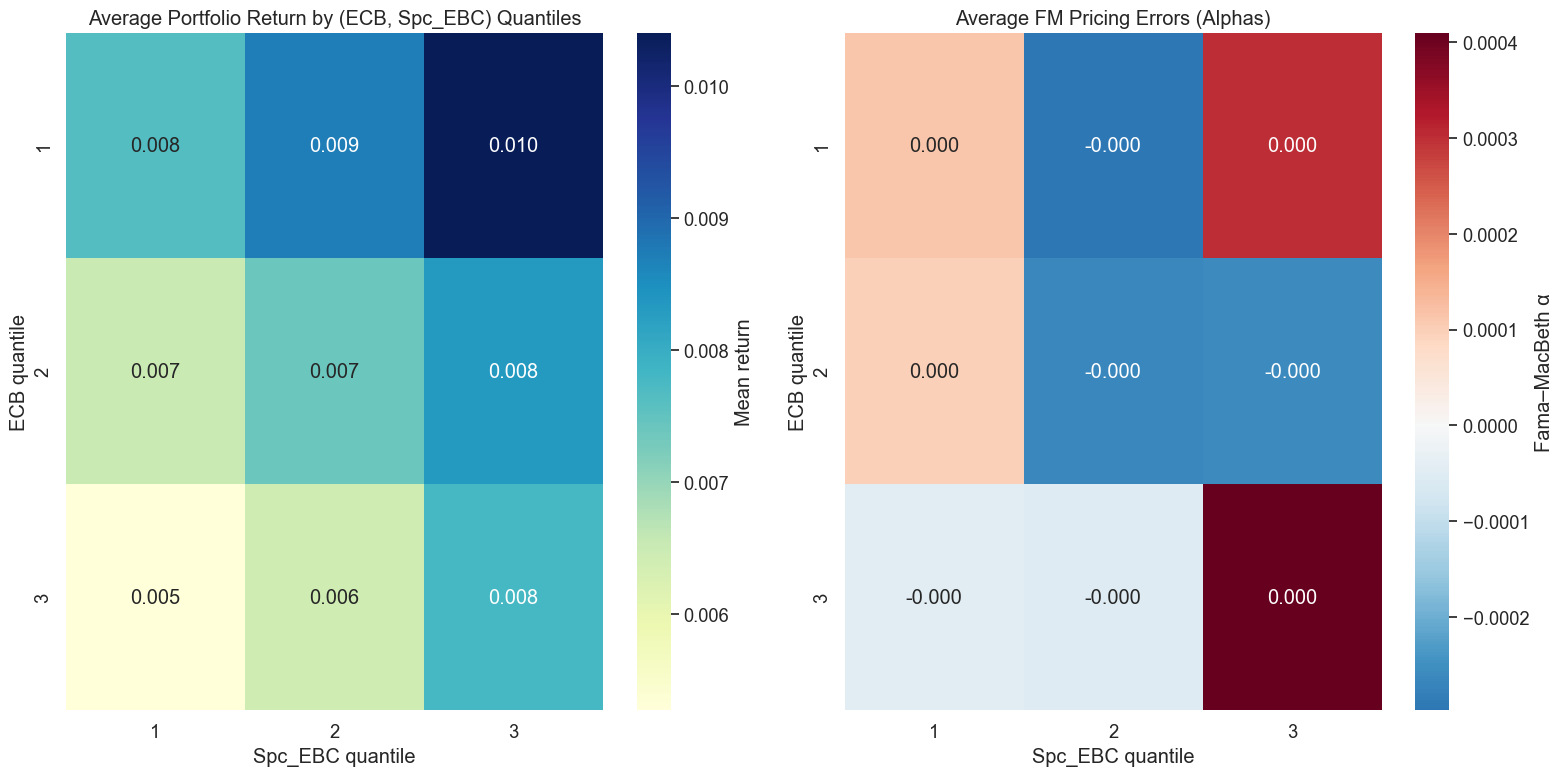

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# set up figure aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# heatmap 1: mean returns
sns.heatmap(
    mean_grid.astype(float),
    ax=axes[0],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    cbar_kws={'label': 'Mean return'}
)
axes[0].set_title("Average Portfolio Return by (ECB, Spc_EBC) Quantiles")
axes[0].set_xlabel("Spc_EBC quantile")
axes[0].set_ylabel("ECB quantile")

# heatmap 2: FM alpha (pricing errors)
sns.heatmap(
    alpha_grid.astype(float),
    ax=axes[1],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    cbar_kws={'label': 'Fama–MacBeth α'}
)
axes[1].set_title("Average FM Pricing Errors (Alphas)")
axes[1].set_xlabel("Spc_EBC quantile")
axes[1].set_ylabel("ECB quantile")

plt.tight_layout()
plt.show()


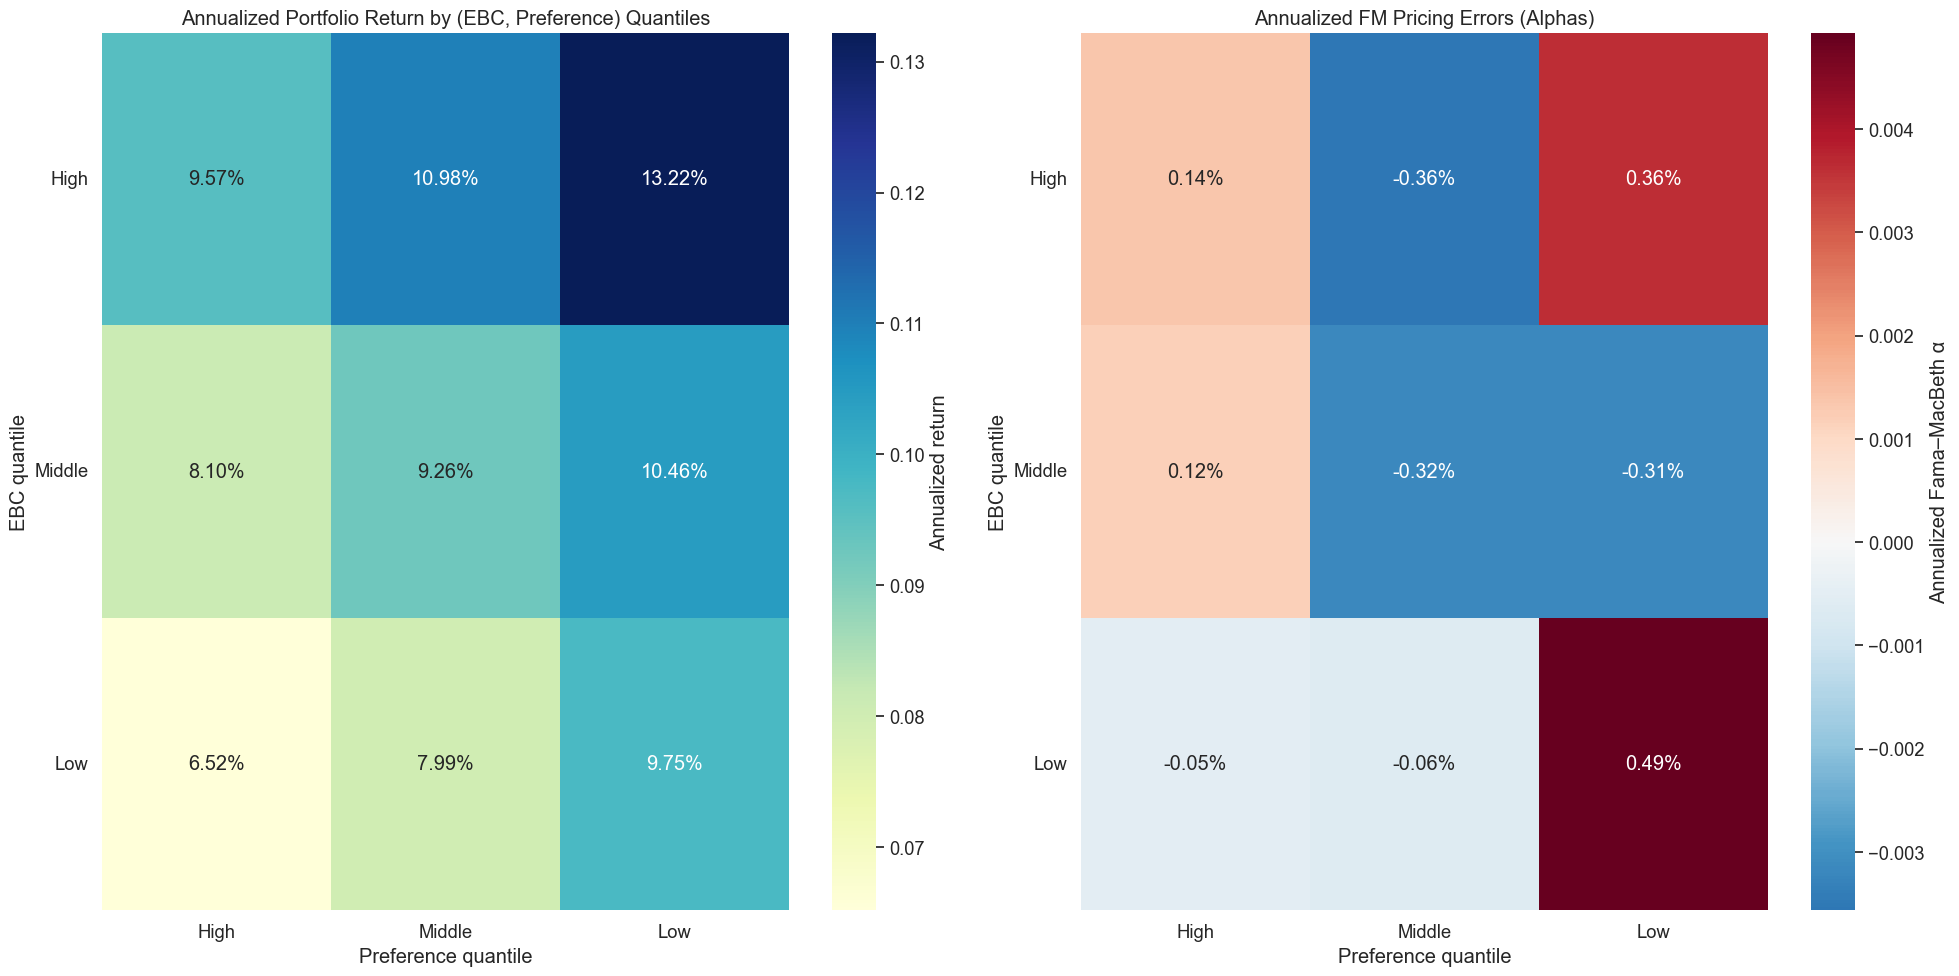

In [15]:
# annualize the grids
mean_grid_annual = (1 + mean_grid.astype(float))**12 - 1
alpha_grid_annual = (1 + alpha_grid.astype(float))**12 - 1

# plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

labels = ['High', 'Middle', 'Low']

# heatmap 1: mean returns annualized
sns.heatmap(
    mean_grid_annual,
    ax=axes[0],
    cmap="YlGnBu",
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized return'}
)
axes[0].set_title("Annualized Portfolio Return by (EBC, Preference) Quantiles")
axes[0].set_xlabel("Preference quantile")
axes[0].set_ylabel("EBC quantile")
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels, rotation=0)


# heatmap 2: FM alpha annualized
sns.heatmap(
    alpha_grid_annual,
    ax=axes[1],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized Fama–MacBeth α'}
)
axes[1].set_title("Annualized FM Pricing Errors (Alphas)")
axes[1].set_xlabel("Preference quantile")
axes[1].set_ylabel("EBC quantile")
axes[1].set_xticklabels(labels)
axes[1].set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


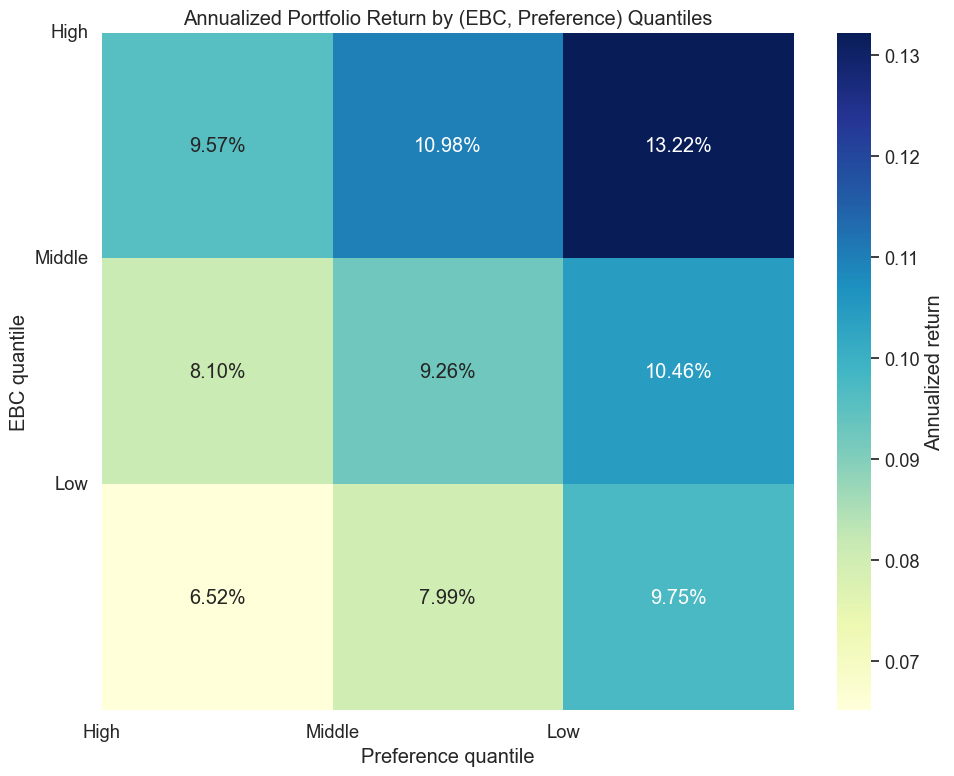

In [16]:
# annualize the mean grid
mean_grid_annual = (1 + mean_grid.astype(float))**12 - 1

# plot heatmap for annualized portfolio returns
plt.figure(figsize=(10, 8))

labels = ['High', 'Middle', 'Low']

sns.heatmap(
    mean_grid_annual,
    cmap="YlGnBu",
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized return'}
)
plt.title("Annualized Portfolio Return by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=[0, 1, 2], labels=labels)
plt.yticks(ticks=[0, 1, 2], labels=labels, rotation=0)

plt.tight_layout()
plt.show()


In [17]:
quantile_map_df 


stocks
date       q1 q2                                                   
1970-01-01 1  1   [BX, C, ETN, FT, HW, M, OLN, COP, TG, R, FL, D...
              2   [ACF, HON, CBO, GD, GSX, GR, LCE, WEAR, SLB, S...
              3   [ACS, AMO, AR, A, JI, CDP, CUD, KSU, RDGE, UV,...
           2  1   [UIS, COT, GM, GMBL, ITT, MZ, MAY, RCA, SY, ST...
              2   [AN, AST, ARC, BS, CGG, DD, FST, KRA, MHT, MYG...
...                                                             ...
2024-12-01 2  2   [HON, FI, FAST, LH, LIN, OTIS, GEHC, WFC, AVY,...
              3   [ADM, CPAY, TRGP, PSX, SLB, CVX, EIX, KR, VICI...
           3  1   [MSFT, CDNS, WM, META, NOW, PANW, GOOG, LW, IN...
              2   [ED, LYB, IBM, KMI, FANG, PEP, AMGN, PAYC, HSY...
              3   [KO, DTE, XOM, GD, HII, MPC, PCG, ABBV, MO, CO...

[5940 rows x 1 columns]

In [18]:
latest_date = quantile_map_df.index.get_level_values('date').max()
date = '2020-04-01'
subset = quantile_map_df.loc[(date, 1, 1), 'stocks']

#flatten lists into a single list
all_stocks = [stk for stk in subset]

#sort alphabetically (optional)
#all_stocks = sorted([stk for sublist in subset for stk in sublist])

for stk in all_stocks:
    print(stk)

SIVB
XOM
GE
PBCT
GM.1
HCA
APTV
HLT
AMAT
HPE
RTX
FOXA
FOX
AAL
WRK
EMR
DOV
MAS
MTB
WFC
DXC
PH
SWK
VFC
JPM
LRCX
RHI
MU
BAC.1
SNA
PNC
AMD
USB
WDC
MS.1
MYL
RJF
STT
PRGO
MCHP
FLIR
BWA
IT
EMN
NTAP
ROK.1
URI
MAR.1
BBY
GS
ALGN
KMX
DISCA
IPGP


Mean Excess Return: 9.9915
Volatility: 0.1894
Sharpe Ratio: 0.5276
              Market
date                
1960-01-01 -0.067093
1960-02-01  0.017111
1960-03-01 -0.010623
1960-04-01 -0.013724
1960-05-01  0.037913
              Market
date                
1967-01-01  0.079115
1967-02-01  0.006439
1967-03-01  0.040107
1967-04-01  0.044258
1967-05-01 -0.047915
Market Mean Return: 12.7503
Market Volatility: 0.1523
Market Sharpe Ratio: 0.8371


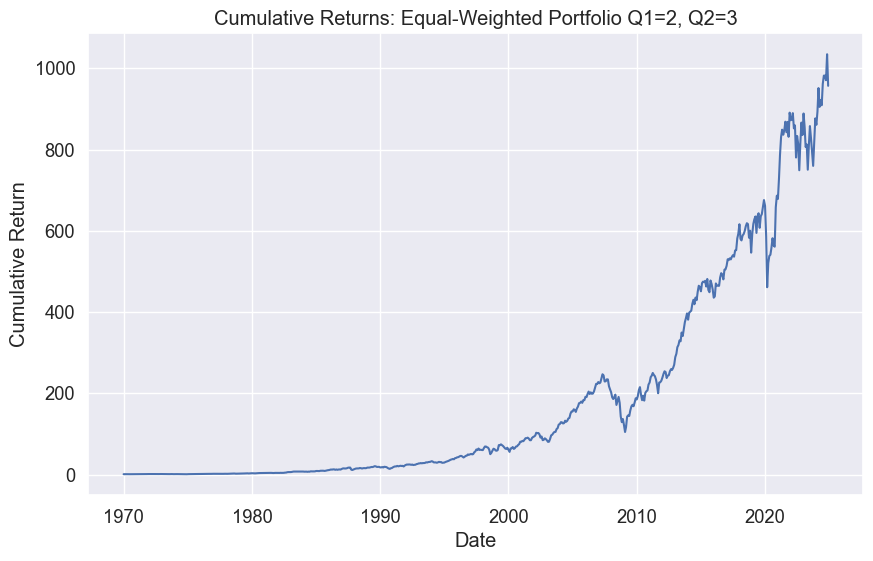

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamps

sp_caps = pd.read_csv('sp500_market_caps.csv', index_col=0)
sp_caps.index = pd.to_datetime(sp_caps.index).to_period('M').start_time

quantile_map_df = quantile_map_df.copy()

quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')

target_q1, target_q2 = 2, 3  #1 is high exposrue and 3 is low exposure


#compute monthly equal-weighted returns

months = sp_500.index.to_period('M').sort_values().unique()
portfolio_returns = []

for month in months:
    # select rows for this month and target quantile levels using MultiIndex
    mask = (
        (quantile_map_df['month'] == month) &
        (quantile_map_df.index.get_level_values('q1') == target_q1) &
        (quantile_map_df.index.get_level_values('q2') == target_q2)
    )
    subset = quantile_map_df.loc[mask, 'stocks']

    if subset.empty:
        portfolio_returns.append(np.nan)
        continue

    # flatten all stock lists and remove duplicates
    tickers = sorted(set([stk for sublist in subset for stk in sublist]))
    if len(tickers) == 0:
        portfolio_returns.append(np.nan)
        continue

    # select returns for these tickers in this month
    ret = sp_500.loc[sp_500.index.to_period('M') == month, tickers].mean(axis=1).values[0]
    portfolio_returns.append(ret)


portfolio_returns_series = pd.Series(portfolio_returns, index=months.to_timestamp())
excess_returns_series = portfolio_returns_series.subtract(rf, axis=0)
mean_return = excess_returns_series.mean() 
vol = excess_returns_series.std() 
sharpe_ratio = mean_return / vol
print(f"Mean Excess Return: {mean_return * 1200:.4f}")
print(f"Volatility: {vol * np.sqrt(12):.4f}")
print(f"Sharpe Ratio: {sharpe_ratio * np.sqrt(12):.4f}")

cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.columns = ["Market"]
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').start_time
print(cap_weighted.head())

excess_returns_cap_weighted = cap_weighted.subtract(rf, axis=0).dropna()
print(excess_returns_cap_weighted.head())

cap_weighted_mean = excess_returns_cap_weighted["Market"].mean()
vol_market = excess_returns_cap_weighted["Market"].std()
sharpe_market = cap_weighted_mean / vol_market
print(f"Market Mean Return: {cap_weighted_mean * 1200:.4f}")
print(f"Market Volatility: {vol_market * np.sqrt(12):.4f}")
print(f"Market Sharpe Ratio: {sharpe_market * np.sqrt(12):.4f}")


cumulative_returns = (1 + portfolio_returns_series).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative_returns.index, cumulative_returns.values)
plt.title(f'Cumulative Returns: Equal-Weighted Portfolio Q1={target_q1}, Q2={target_q2}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()


[0.07531414 0.00333204 0.00315335 0.00194424 0.03938519 0.02058686
 0.11040948 0.00950025 0.00336551 0.01167286 0.02157427 0.02484203
 0.00505379 0.01184613 0.00357813 0.01626453 0.01937504 0.00555595
 0.03650018 0.00588501 0.00643825 0.00323276 0.03328116 0.00641586
 0.02486346 0.003643   0.02531573 0.00687051 0.00284016 0.00631226
 0.01197577 0.00866292 0.03579797 0.00866586 0.08614218 0.01084175
 0.01632561 0.00426278 0.00524062 0.00337864 0.03282995 0.00676848
 0.00480367 0.00225514 0.00254815 0.007001   0.06807336 0.03923054
 0.05728591 0.00868654 0.003236   0.00977259 0.00812751 0.00756282
 0.00217213]
[0.06479573 0.00272275 0.0272399  0.00275258 0.00175421 0.03763602
 0.01794662 0.09834819 0.00879544 0.05539049 0.00940014 0.02018661
 0.02288659 0.01401117 0.00317499 0.01324815 0.06572652 0.02057068
 0.03131283 0.00389189 0.00504535 0.00703742 0.00269092 0.01860022
 0.00308052 0.01647695 0.0085477  0.02541488 0.00306424 0.02692795
 0.00634361 0.02930851 0.00724798 0.01823638 0.01

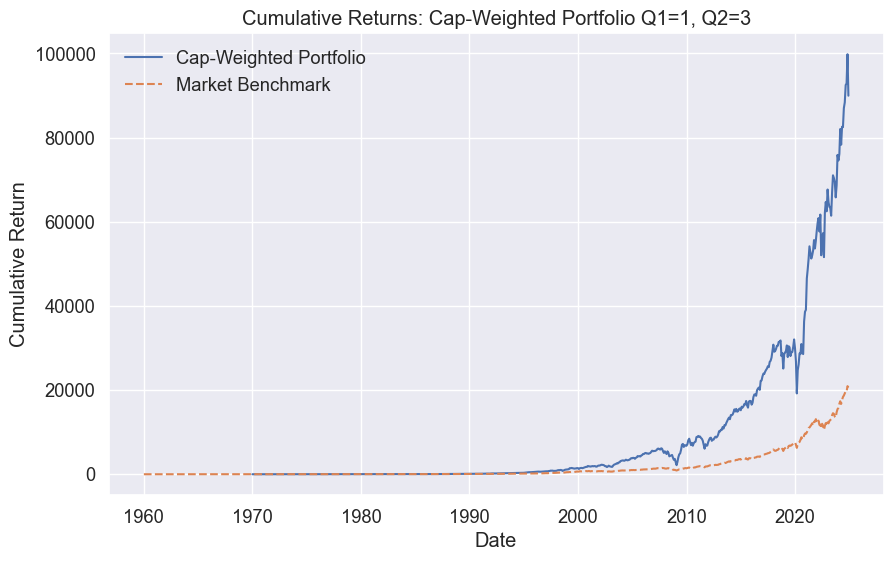

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load and align data ---
sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamps

sp_caps = pd.read_csv('sp500_market_caps.csv', index_col=0)
sp_caps.index = pd.to_datetime(sp_caps.index).to_period('M').start_time

quantile_map_df = quantile_map_df.copy()
quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')

target_q1, target_q2 = 1, 3  # 1 = high exposure, 3 = low exposure

# --- Compute monthly cap-weighted returns ---
months = sp_500.index.to_period('M').sort_values().unique()
portfolio_returns = []

for month in months:
    # select rows for this month and target quantile levels
    mask = (
        (quantile_map_df['month'] == month) &
        (quantile_map_df.index.get_level_values('q1') == target_q1) &
        (quantile_map_df.index.get_level_values('q2') == target_q2)
    )
    subset = quantile_map_df.loc[mask, 'stocks']

    if subset.empty:
        portfolio_returns.append(np.nan)
        continue

    # flatten and remove duplicates
    tickers = sorted(set([stk for sublist in subset for stk in sublist]))
    if len(tickers) == 0:
        portfolio_returns.append(np.nan)
        continue

    # select returns and caps for these tickers in this month
    ret_row = sp_500.loc[sp_500.index.to_period('M') == month, tickers]
    caps_row = sp_caps.loc[sp_caps.index.to_period('M') == month, tickers]

    # handle missing tickers
    valid_tickers = [t for t in tickers if t in caps_row.columns and not np.isnan(caps_row[t].values[0])]
    if len(valid_tickers) == 0:
        portfolio_returns.append(np.nan)
        continue

    ret_row = ret_row[valid_tickers]
    caps_row = caps_row[valid_tickers]

    # normalize caps to sum to 1
    weights = caps_row.values[0]
    weights = weights / np.nansum(weights)
    print(weights)

    # cap-weighted return
    ret = np.nansum(ret_row.values[0] * weights)
    portfolio_returns.append(ret)

# --- Compute performance metrics ---
portfolio_returns_series = pd.Series(portfolio_returns, index=months.to_timestamp())

# --- Compare to market benchmark ---
cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').start_time
cap_weighted.columns = ["Market"]

excess_returns_series = portfolio_returns_series.subtract(rf, axis=0)
mean_return = excess_returns_series.mean()
vol = excess_returns_series.std()
sharpe_ratio = mean_return / vol

print(f"Cap-Weighted Mean Excess Return: {mean_return * 1200:.4f}")
print(f"Cap-Weighted Volatility: {vol * np.sqrt(12):.4f}")
print(f"Cap-Weighted Sharpe Ratio: {sharpe_ratio * np.sqrt(12):.4f}")


cap_weighted_mean = cap_weighted["Market"].mean()
vol_market = cap_weighted["Market"].std()
sharpe_market = cap_weighted_mean / vol_market
print(f"Market Mean Return: {cap_weighted_mean * 1200:.4f}")
print(f"Market Volatility: {vol_market * np.sqrt(12):.4f}")
print(f"Market Sharpe Ratio: {sharpe_market * np.sqrt(12):.4f}")

# --- Plot cumulative returns ---
cumulative_returns = (1 + portfolio_returns_series).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative_returns.index, cumulative_returns.values, label='Cap-Weighted Portfolio')
plt.plot((1 + cap_weighted["Market"]).cumprod(), label='Market Benchmark', linestyle='--')
plt.title(f'Cumulative Returns: Cap-Weighted Portfolio Q1={target_q1}, Q2={target_q2}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.legend()
plt.show()

DatetimeIndex(['1970-01-01', '1970-02-01', '1970-03-01', '1970-04-01',
               '1970-05-01', '1970-06-01', '1970-07-01', '1970-08-01',
               '1970-09-01', '1970-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=660, freq='MS')
DatetimeIndex(['1960-01-01', '1960-02-01', '1960-03-01', '1960-04-01',
               '1960-05-01', '1960-06-01', '1960-07-01', '1960-08-01',
               '1960-09-01', '1960-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=780, freq='MS')


date
2024-08-01    88367.989174
2024-09-01    92495.152186
2024-10-01    92887.526021
2024-11-01    99813.459804
2024-12-01    89967.810303
Freq: MS, dtype: float64

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3,Market
date,,,,,,,,,,
1967-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.007870,-0.004765,-0.000838,0.017400,0.029910,0.016337,0.043306,0.045670,0.037357,0.023316
2024-09-01,0.011322,0.037803,0.038071,0.020492,0.028695,-0.003960,0.008222,0.009332,0.007825,0.021856
2024-10-01,-0.052169,-0.006435,-0.024341,-0.012148,-0.010471,-0.015406,-0.023296,-0.023388,-0.021076,-0.008686


0.09174823032715923
0.23846112999446617
aaaaa
0.104622207552581
0.22469721939397963
aaaaa
0.12483052690819131
0.2585405137444306
aaaaa
0.0781073870390728
0.18369623055814926
aaaaa
0.08886213166258056
0.1714224322525781
aaaaa
0.0999151018530531
0.1893767379376673
aaaaa
0.0632894621644644
0.16632033109494532
aaaaa
0.07713781309609194
0.13429558143390957
aaaaa
0.09343655802571083
0.1499631279970252
aaaaa


,Q1,Q2,Q3
Q1,0.384751,0.465614,0.482828
Q2,0.425199,0.518381,0.527600
Q3,0.380528,0.574388,0.623064


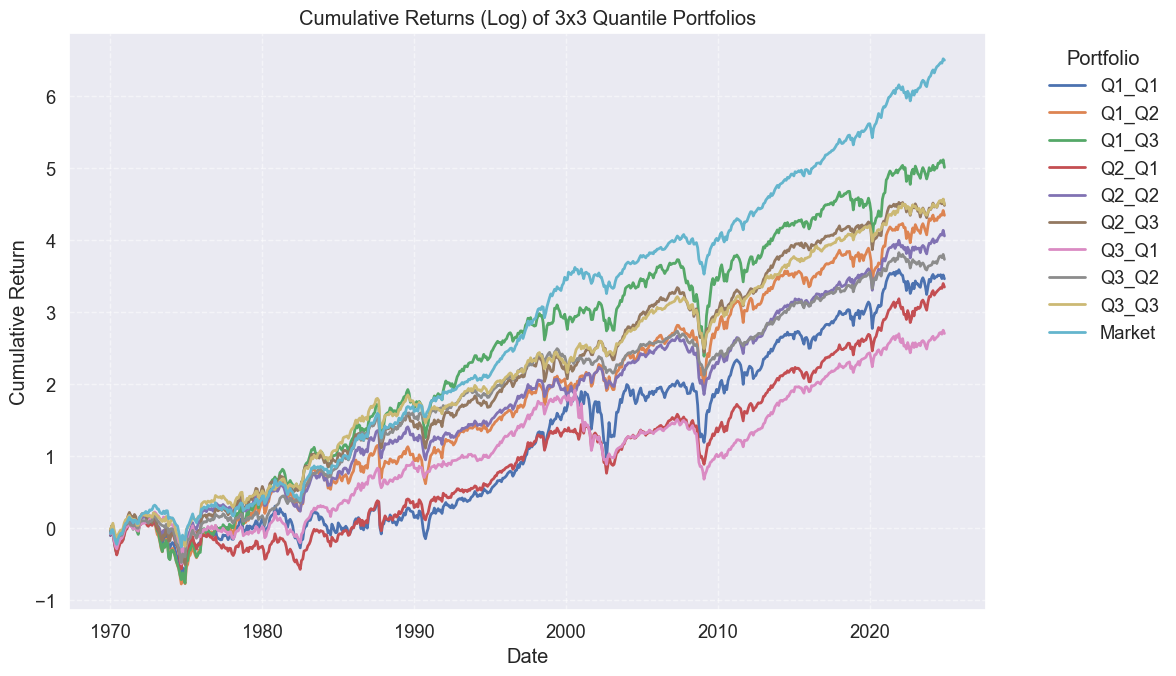

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###Equal weighted portfolios

sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamps

quantile_map_df = quantile_map_df.copy()
quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')


n_q1, n_q2 = 3, 3  # 3x3 grid
months = quantile_map_df.index.get_level_values('date').to_period('M').sort_values().unique()

# Container for all portfolio returns
all_portfolio_returns = pd.DataFrame(index=months.to_timestamp())

#iterate over quantile portfolios and calculate log returns
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        portfolio_returns = []
        for month in months:
            # select rows for this month & quantile cell
            mask = (
                (quantile_map_df['month'] == month) &
                (quantile_map_df.index.get_level_values('q1') == q1) &
                (quantile_map_df.index.get_level_values('q2') == q2)
            )
            subset = quantile_map_df.loc[mask, 'stocks']

            if subset.empty:
                portfolio_returns.append(np.nan)
                continue

            # flatten and remove duplicates
            tickers = sorted(set([stk for sublist in subset for stk in sublist]))
            if len(tickers) == 0:
                portfolio_returns.append(np.nan)
                continue

            # mean return for tickers in this month
            ret = sp_500.loc[sp_500.index.to_period('M') == month, tickers].mean(axis=1).values[0]
            portfolio_returns.append(ret)

        # add to DataFrame
        col_name = f"Q{q1}_Q{q2}"
        all_portfolio_returns[col_name] = portfolio_returns

cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').to_timestamp()
cap_weighted.columns = ["Market"]

# Also make sure all_portfolio_returns has a DatetimeIndex
all_portfolio_returns.index = pd.to_datetime(all_portfolio_returns.index).to_period('M').to_timestamp()

print(all_portfolio_returns.index)
print(cap_weighted.index)

# Find the common index
common_index = all_portfolio_returns.index.intersection(cap_weighted.index)

# Align both to the common index
cap_weighted = cap_weighted.loc[common_index]
all_portfolio_returns = all_portfolio_returns.loc[common_index]

all_portfolio_returns["Market"] = cap_weighted["Market"]

all_portfolio_returns = all_portfolio_returns.subtract(rf, axis=0)


# log(1 + r) for each month
log_returns = np.log1p(all_portfolio_returns)
# cumulative log return
cumulative_log_returns = log_returns.cumsum()
# optionally convert back to normal cumulative return

display(cumulative_returns.tail())

display(all_portfolio_returns)

sharpe_matrix_EW = pd.DataFrame(index=[f"Q{i}" for i in range(1, n_q1 + 1)],
                             columns=[f"Q{j}" for j in range(1, n_q2 + 1)])

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()

        if len(returns) < 3:
            sharpe = np.nan
        else:
            mean_ret = returns.mean()   # annualized mean
            print(mean_ret * 12)
            vol = returns.std()   # annualized vol
            print(vol * np.sqrt(12))
            print("aaaaa")
            sharpe = mean_ret / vol if vol != 0 else np.nan
            sharpe *= np.sqrt(12)

        sharpe_matrix_EW.loc[f"Q{q1}", f"Q{q2}"] = sharpe

# Convert to numeric for plotting or exporting
sharpe_matrix_EW = sharpe_matrix_EW.astype(float)

display(sharpe_matrix_EW)

#plot
plt.figure(figsize=(12,7))
for col in cumulative_log_returns.columns:
    plt.plot(cumulative_log_returns.index, cumulative_log_returns[col], label=col, linewidth=2)

plt.title("Cumulative Returns (Log) of 3x3 Quantile Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(title='Portfolio', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
import numpy as np
from tabulate import tabulate  # for nice console tables

summary_data = []

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()

        if len(returns) < 3:
            mean_annual = np.nan
            vol_annual = np.nan
            sharpe_annual = np.nan
        else:
            mean_monthly = returns.mean()
            vol_monthly = returns.std()

            mean_annual = mean_monthly * 12 
            vol_annual = vol_monthly * np.sqrt(12)
            sharpe_annual = (mean_monthly / vol_monthly) * np.sqrt(12) if vol_monthly != 0 else np.nan

        summary_data.append([f"Q{q1}_Q{q2}", mean_annual, vol_annual, sharpe_annual])

# Create DataFrame
summary_df = pd.DataFrame(summary_data, columns=["Quantile", "Annualized Mean Return", "Annualized Std Dev", "Annualized Sharpe"])

# Round for readability
summary_df = summary_df.round(3)

# Display as pretty table in console
print(tabulate(summary_df, headers="keys", tablefmt="fancy_grid", showindex=False))

# Optionally, to display in Jupyter with style:
display(summary_df.style.background_gradient(cmap="Blues")
                           .format({
                               "Annualized Mean Return": "{:.2%}",
                               "Annualized Std Dev": "{:.2%}",
                               "Annualized Sharpe": "{:.2f}"
                           })
                           .set_table_styles(
                               [{'selector': 'th', 'props': [('background-color', '#0E1117'),
                                                             ('color', 'white'),
                                                             ('font-weight', 'bold')]}]
                           )
)


╒════════════╤══════════════════════════╤══════════════════════╤═════════════════════╕
│ Quantile   │   Annualized Mean Return │   Annualized Std Dev │   Annualized Sharpe │
╞════════════╪══════════════════════════╪══════════════════════╪═════════════════════╡
│ Q1_Q1      │                    0.092 │                0.238 │               0.385 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q1_Q2      │                    0.105 │                0.225 │               0.466 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q1_Q3      │                    0.125 │                0.259 │               0.483 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q2_Q1      │                    0.078 │                0.184 │               0.425 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q2_Q2      │                    0.089 │  

,Quantile,Annualized Mean Return,Annualized Std Dev,Annualized Sharpe
0,Q1_Q1,9.20%,23.80%,0.39
1,Q1_Q2,10.50%,22.50%,0.47
2,Q1_Q3,12.50%,25.90%,0.48
3,Q2_Q1,7.80%,18.40%,0.42
4,Q2_Q2,8.90%,17.10%,0.52
5,Q2_Q3,10.00%,18.90%,0.53
6,Q3_Q1,6.30%,16.60%,0.38
7,Q3_Q2,7.70%,13.40%,0.57
8,Q3_Q3,9.30%,15.00%,0.62


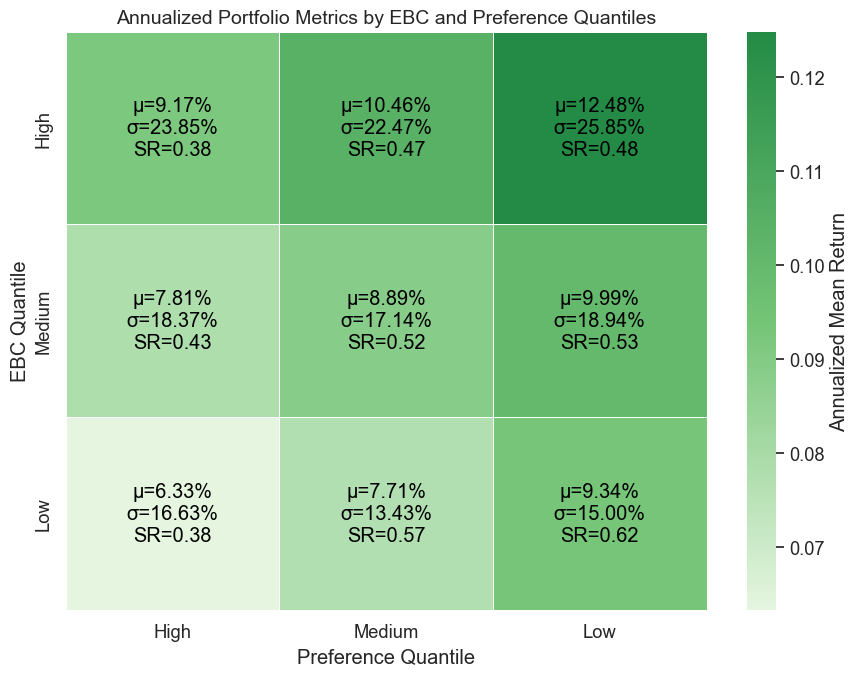

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Label mappings
ebc_labels = {1: "High", 2: "Medium", 3: "Low"}
pref_labels = {1: "High", 2: "Medium", 3: "Low"}

# Initialize nested dicts for results
heatmap_data = {}
mean_data = {}

for q1 in range(1, n_q1 + 1):
    ebc_label = ebc_labels[q1]
    heatmap_data[ebc_label] = {}
    mean_data[ebc_label] = {}
    for q2 in range(1, n_q2 + 1):
        pref_label = pref_labels[q2]
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()

        if len(returns) < 3:
            mean_annual = np.nan
            vol_annual = np.nan
            sharpe_annual = np.nan
        else:
            mean_monthly = returns.mean()
            vol_monthly = returns.std()

            mean_annual = mean_monthly * 12
            vol_annual = vol_monthly * np.sqrt(12)
            sharpe_annual = (mean_monthly / vol_monthly) * np.sqrt(12) if vol_monthly != 0 else np.nan

        mean_data[ebc_label][pref_label] = mean_annual
        heatmap_data[ebc_label][pref_label] = (
            f"μ={mean_annual:.2%}\n"
            f"σ={vol_annual:.2%}\n"
            f"SR={sharpe_annual:.2f}"
        )

# Convert to DataFrames
heatmap_df = pd.DataFrame(heatmap_data).T
mean_df = pd.DataFrame(mean_data).T  # numeric values for coloring

# Custom soft-green colormap
colors = ["#e5f5e0", "#74c476", "#238b45"]  # light → medium → deeper green
green_cmap = LinearSegmentedColormap.from_list("custom_green", colors)

# Plot
plt.figure(figsize=(9, 7))
sns.heatmap(
    mean_df,
    cmap=green_cmap,
    annot=heatmap_df,
    fmt="",
    linewidths=0.7,
    annot_kws={"color": "black"},
    cbar_kws={'label': 'Annualized Mean Return'},
)

plt.title("Annualized Portfolio Metrics by EBC and Preference Quantiles", fontsize=14)
plt.xlabel("Preference Quantile")
plt.ylabel("EBC Quantile")
plt.tight_layout()
plt.show()


1_1
0.1331918079994895
0.221848160458476
aaaaa
1_2
0.11136800291056184
0.21178263015312404
aaaaa
1_3
0.11071771274647065
0.24179549297059727
aaaaa
2_1
0.09667921643656607
0.17843871786084067
aaaaa
2_2
0.08338350294019478
0.15597832488598287
aaaaa
2_3
0.10787543303491551
0.16776415748553716
aaaaa
3_1
0.05990392119471159
0.1711425890976797
aaaaa
3_2
0.05205111429293194
0.12088942361299197
aaaaa
3_3
0.07779524652871676
0.13513087147409952
aaaaa
Market
0.1510257480173852
0.1450742238375928


,Q1,Q2,Q3
Q1,0.600374,0.525860,0.457898
Q2,0.541806,0.534584,0.643018
Q3,0.350023,0.430568,0.575703


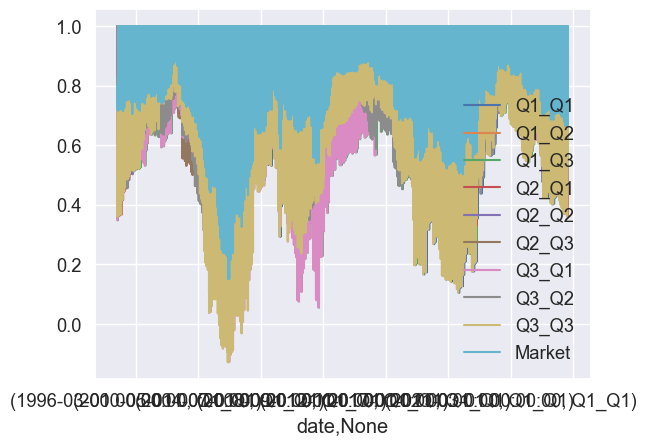

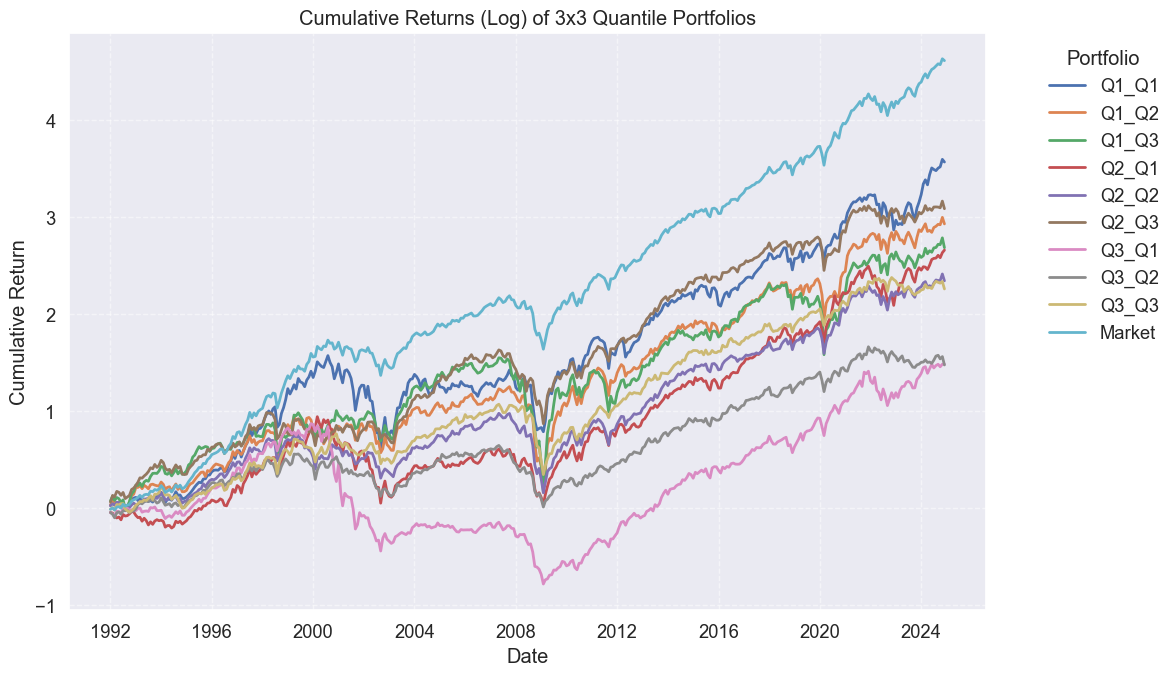

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#this is the important one


sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamp
sp_caps = pd.read_csv('sp500_market_caps.csv', index_col=0)
sp_caps.index = pd.to_datetime(sp_caps.index).to_period('M').start_time  # monthly timestamp

quantile_map_df = quantile_map_df.copy()
quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')


n_q1, n_q2 = 3, 3  # 3x3 grid
# build quarterly rebalance schedule
months = quantile_map_df.index.get_level_values('date').to_period('M').sort_values().unique()
rebalance_months = months[months.month % 3 == 1]  # Jan, Apr, Jul, Oct

# map each month to most recent rebalance
month_to_rebalance = {}
current_reb = None
for m in months:
    if m in rebalance_months:
        current_reb = m
    month_to_rebalance[m] = current_reb

all_portfolio_returns = pd.DataFrame(index=months.to_timestamp())

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        portfolio_returns = []
        
        for month in months:
            reb_m = month_to_rebalance[month]  # key change
            
            # weight selection uses rebalance month
            mask = (
                (quantile_map_df['month'] == reb_m) &
                (quantile_map_df.index.get_level_values('q1') == q1) &
                (quantile_map_df.index.get_level_values('q2') == q2)
            )
            subset = quantile_map_df.loc[mask, 'stocks']

            if subset.empty:
                portfolio_returns.append(np.nan)
                continue

            # tickers based on rebalance month
            tickers = sorted(set([stk for sublist in subset for stk in sublist]))

            # returns use the *current month*
            ret_row = sp_500.loc[sp_500.index.to_period('M') == month, tickers]

            # weights use the *rebalance month*
            caps_row = sp_caps.loc[sp_caps.index.to_period('M') == reb_m, tickers]

            # validity checks...
            valid_tickers = [t for t in tickers if t in caps_row.columns and not np.isnan(caps_row[t].values[0])]
            if len(valid_tickers) == 0:
                portfolio_returns.append(np.nan)
                continue

            ret_row = ret_row[valid_tickers]
            caps_row = caps_row[valid_tickers]

            # compute fixed weights for this quarter
            weights = caps_row.values[0]
            weights = weights / np.nansum(weights)

            # compute return for this month (weights are frozen)
            ret = np.nansum(ret_row.values[0] * weights)
            portfolio_returns.append(ret)

        all_portfolio_returns[f"Q{q1}_Q{q2}"] = portfolio_returns

        
cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').to_timestamp()
cap_weighted.columns = ["Market"]

# Also make sure all_portfolio_returns has a DatetimeIndex
all_portfolio_returns.index = pd.to_datetime(all_portfolio_returns.index).to_period('M').to_timestamp()

# Find the common index
common_index = all_portfolio_returns.index.intersection(cap_weighted.index)

# Align both to the common index
cap_weighted = cap_weighted.loc[common_index]
all_portfolio_returns = all_portfolio_returns.loc[common_index]

#this is to look at shorter periods of time
start_date = '1992-01-01'

all_portfolio_returns = all_portfolio_returns.subtract(rf, axis=0)
all_portfolio_returns["Market"] = cap_weighted["Market"]
all_portfolio_returns = all_portfolio_returns.loc[all_portfolio_returns.index >= start_date]
all_portfolio_returns = all_portfolio_returns.subtract(rf, axis=0).dropna()

all_portfolio_returns.to_csv('Quantile_capweighted_Portfolio_returns.csv')

(all_portfolio_returns.rolling(window=36).corr()).plot()




# log(1 + r) for each month
log_returns = np.log1p(all_portfolio_returns)
# cumulative log return
cumulative_log_returns = log_returns.cumsum()

sharpe_matrix = pd.DataFrame(index=[f"Q{i}" for i in range(1, n_q1 + 1)],
                             columns=[f"Q{j}" for j in range(1, n_q2 + 1)])

vol_grid = []
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()
        print(f'{q1}_{q2}')
        if len(returns) < 3:
            sharpe = np.nan
        else:
            mean_ret = returns.mean()   # annualized mean
            print(mean_ret * 12)
            vol = returns.std()   # annualized vol
            vol_grid.append(vol * np.sqrt(12))

            print(vol * np.sqrt(12))
            print("aaaaa")
            sharpe = mean_ret / vol if vol != 0 else np.nan
            sharpe *= np.sqrt(12)
        
        sharpe_matrix.loc[f"Q{q1}", f"Q{q2}"] = sharpe

print("Market")
print(all_portfolio_returns["Market"].mean() * 12)
print(all_portfolio_returns["Market"].std() * np.sqrt(12))

# Convert to numeric for plotting or exporting
sharpe_matrix = sharpe_matrix.astype(float)

display(sharpe_matrix)

#plot
plt.figure(figsize=(12,7))
for col in cumulative_log_returns.columns:
    #if col == "Market":
    plt.plot(cumulative_log_returns.index, cumulative_log_returns[col], label=col, linewidth=2)
    #elif col == "Q1_Q3":
        #plt.plot(cumulative_log_returns.index, cumulative_log_returns[col], label=col, linewidth=2)
    #elif col == "Q1_Q1":
        #plt.plot(cumulative_log_returns.index, cumulative_log_returns[col], label=col, linewidth=2)
plt.title("Cumulative Returns (Log) of 3x3 Quantile Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(title='Portfolio', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


        date stock  q1  q2
0 1983-09-01  AAPL   1   1
1 1983-10-01  AAPL   1   1
2 1983-11-01  AAPL   1   1
3 1983-12-01  AAPL   1   1
4 1984-01-01  AAPL   1   1
5 1984-02-01  AAPL   1   1
6 1984-03-01  AAPL   3   1
7 1984-04-01  AAPL   3   1
8 1984-05-01  AAPL   3   1
9 1984-06-01  AAPL   3   1


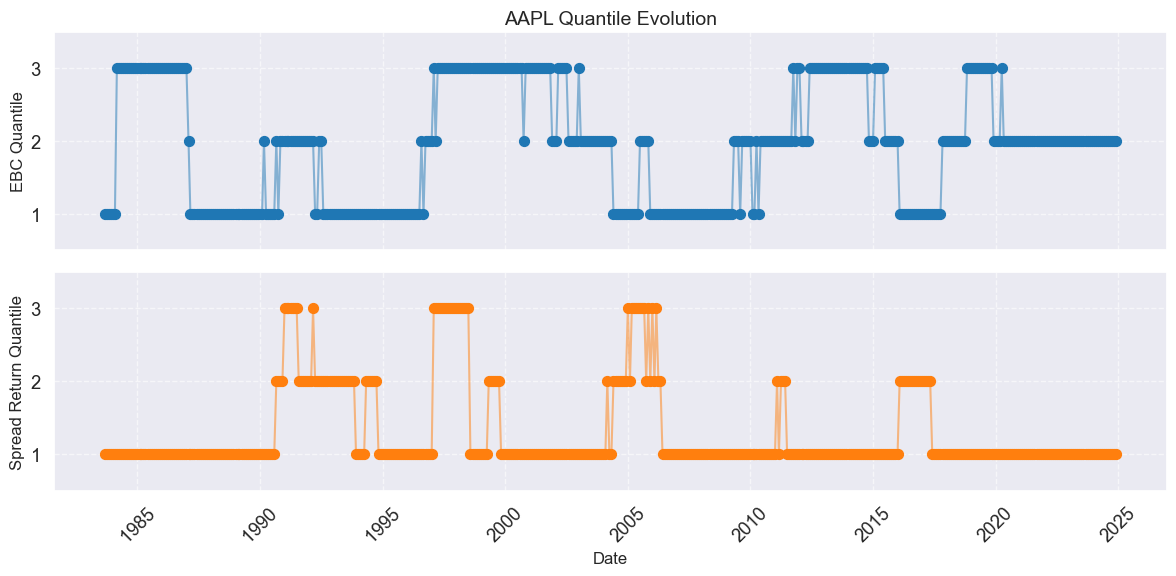

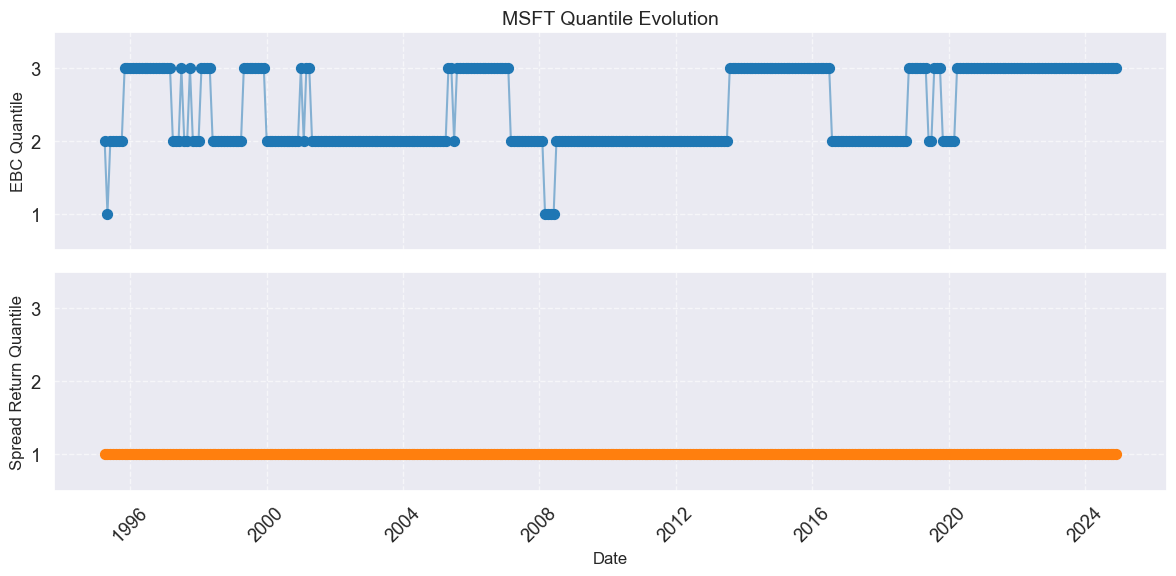

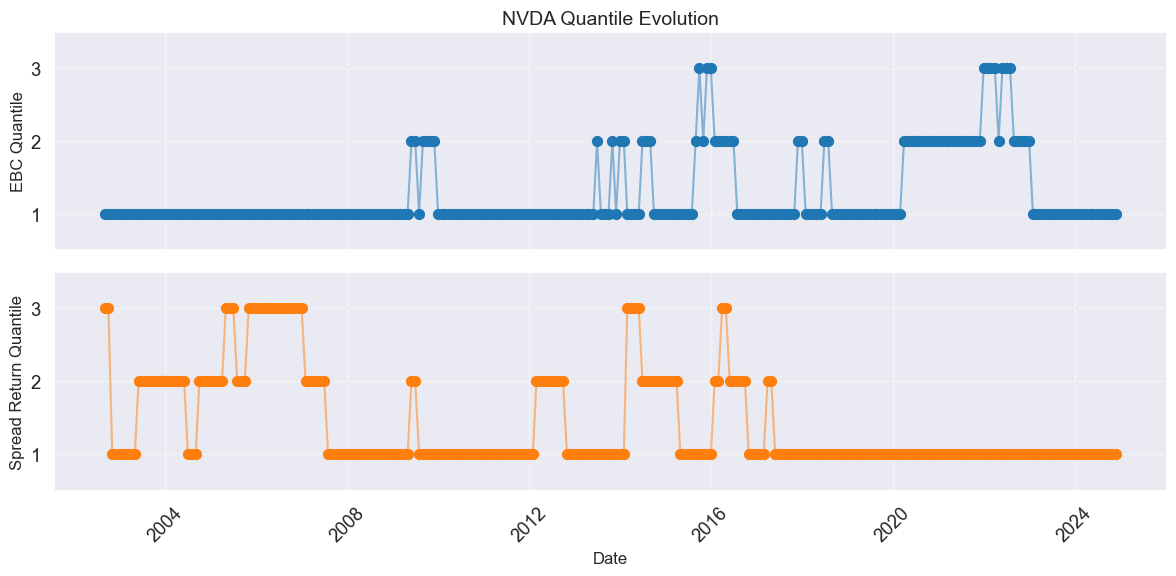

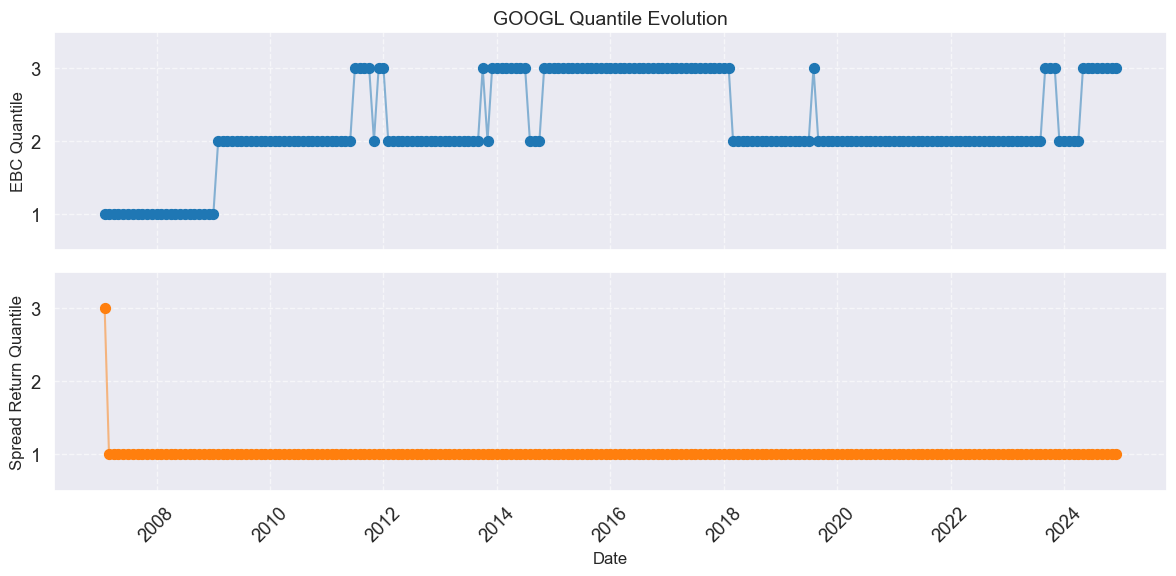

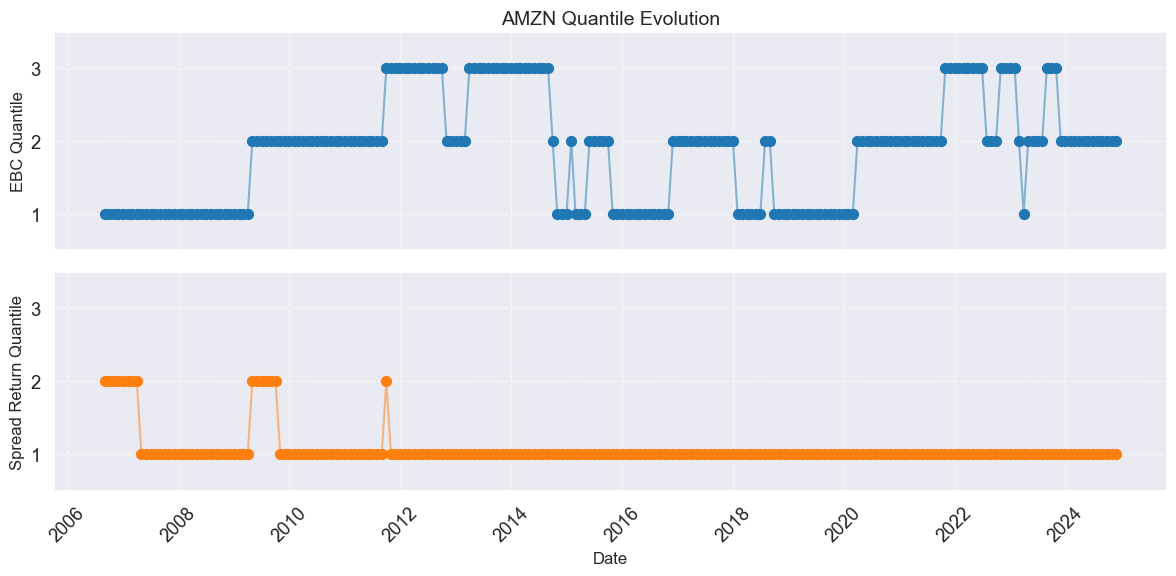

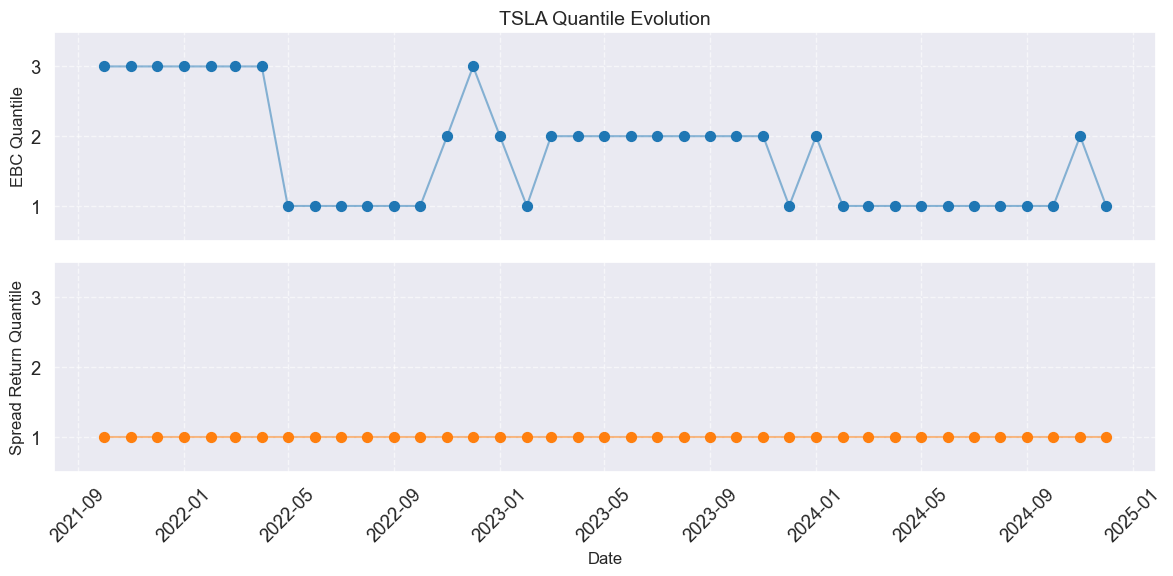

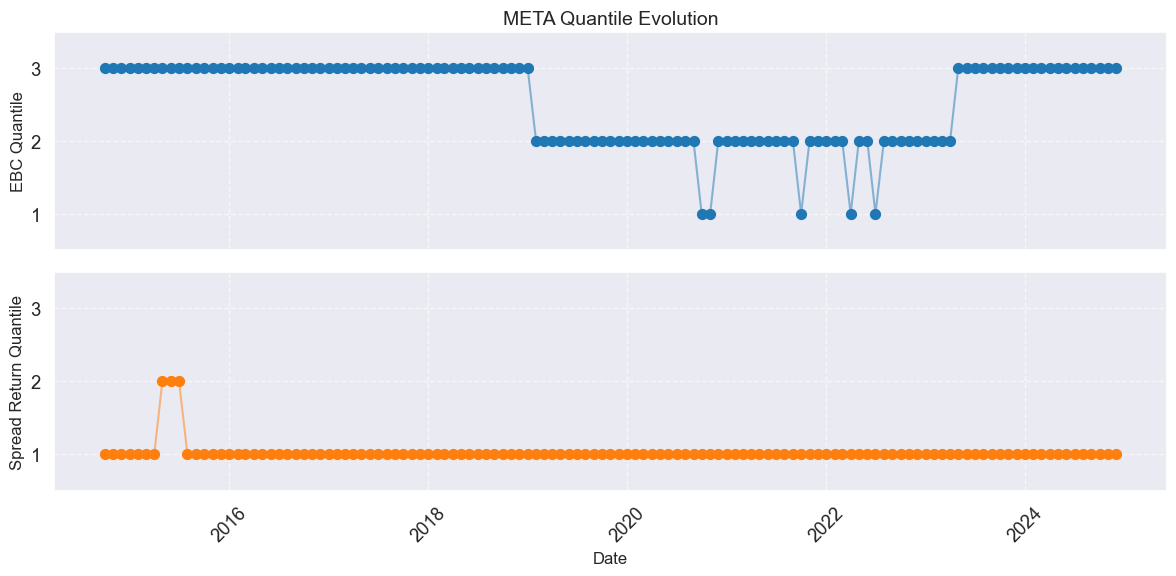

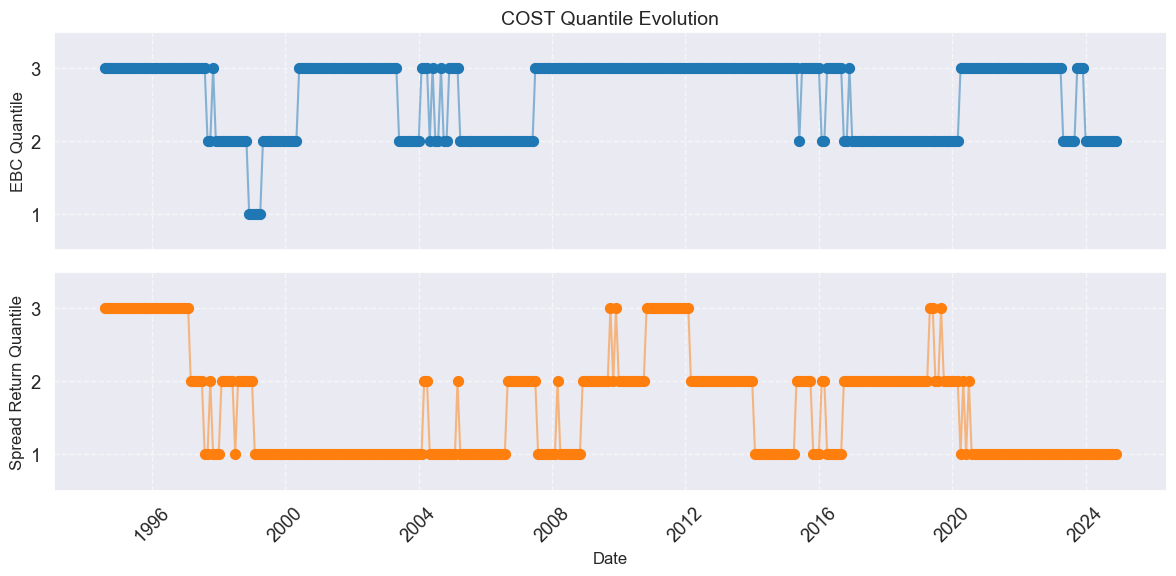

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Inputs ----
tracked_stocks = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'TSLA', 'META', "COST"]   # change to any list of tickers you want to track
start_date = pd.Timestamp('1970-01-01')     # or '2000-01-01' etc.

# Ensure date index is datetime
quantile_map_df = quantile_map_df.copy()
quantile_map_df = quantile_map_df.reset_index()
quantile_map_df['date'] = pd.to_datetime(quantile_map_df['date'])
quantile_map_df = quantile_map_df.set_index(['date', 'q1', 'q2']).sort_index()

# Filter to start_date and available range
quantile_map_df = quantile_map_df.loc[quantile_map_df.index.get_level_values('date') >= start_date]

# Collect results
records = []

for (date, q1, q2), row in quantile_map_df.iterrows():
    stocks_in_cell = row['stocks']
    if not isinstance(stocks_in_cell, list):
        continue
    for stk in tracked_stocks:
        if stk in stocks_in_cell:
            records.append({'date': date, 'stock': stk, 'q1': q1, 'q2': q2})

# Convert to DataFrame
tracking_df = pd.DataFrame(records)
tracking_df = tracking_df.sort_values(['stock', 'date'])

print(tracking_df.head(10))

# ---- Plot each stock's quantile path ----
for stk in tracked_stocks:
    stk_df = tracking_df[tracking_df['stock'] == stk]
    if stk_df.empty:
        print(f"No data for {stk}")
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Plot q1
    axes[0].scatter(stk_df['date'], stk_df['q1'], color='tab:blue', s=50)
    axes[0].plot(stk_df['date'], stk_df['q1'], color='tab:blue', alpha=0.5)
    axes[0].set_ylabel(f'{f1_name} Quantile', fontsize=12)
    axes[0].set_title(f'{stk} Quantile Evolution', fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].set_ylim(0.5, max(tracking_df['q1'].max(), tracking_df['q2'].max()) + 0.5)

    # Plot q2
    axes[1].scatter(stk_df['date'], stk_df['q2'], color='tab:orange', s=50)
    axes[1].plot(stk_df['date'], stk_df['q2'], color='tab:orange', alpha=0.5)
    axes[1].set_ylabel(f'{f2_name} Quantile', fontsize=12)
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].set_ylim(0.5, max(tracking_df['q1'].max(), tracking_df['q2'].max()) + 0.5)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

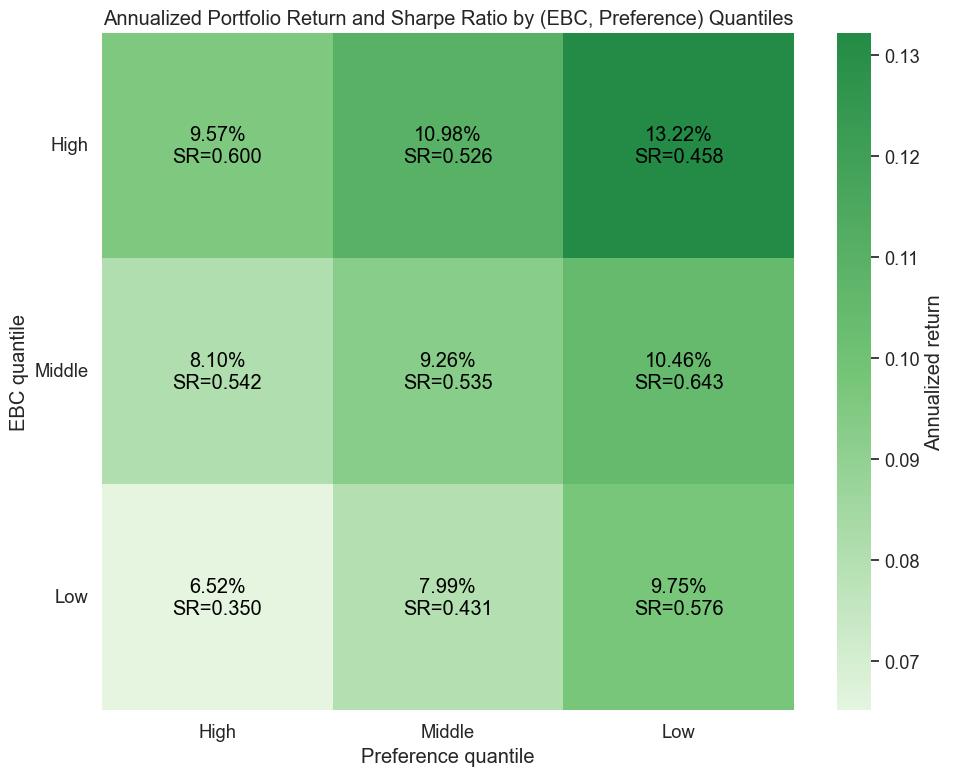

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Ensure consistent index/column labels between the two grids
mean_grid_annual.index = [f"Q{i}" for i in range(1, mean_grid_annual.shape[0] + 1)]
mean_grid_annual.columns = [f"Q{j}" for j in range(1, mean_grid_annual.shape[1] + 1)]

sharpe_matrix.index = [f"Q{i}" for i in range(1, sharpe_matrix.shape[0] + 1)]
sharpe_matrix.columns = [f"Q{j}" for j in range(1, sharpe_matrix.shape[1] + 1)]

# Create annotation text combining returns and Sharpe ratios
annot_text = pd.DataFrame(index=mean_grid_annual.index, columns=mean_grid_annual.columns)

for i in mean_grid_annual.index:
    for j in mean_grid_annual.columns:
        ret = mean_grid_annual.loc[i, j]
        sharpe = sharpe_matrix.loc[i, j]
        if pd.notna(ret) and pd.notna(sharpe):
            annot_text.loc[i, j] = f"{ret:.2%}\nSR={sharpe:.3f}"
        elif pd.notna(ret):
            annot_text.loc[i, j] = f"{ret:.2%}"
        else:
            annot_text.loc[i, j] = ""

# Plot
plt.figure(figsize=(10, 8))
#colors = ["#d9f0d3", "#74c476", "#006d2c"]  # light mint → medium green → dark forest
colors = ["#e5f5e0", "#74c476", "#238b45"]


custom_cmap = LinearSegmentedColormap.from_list("poster_green_gradient", colors)
sns.heatmap(
    mean_grid_annual,
    annot=annot_text,
    fmt="",
    cmap=custom_cmap,
    cbar_kws={'label': 'Annualized return'},
    annot_kws={"color": "black"}
)
plt.title("Annualized Portfolio Return and Sharpe Ratio by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'])
plt.yticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'], rotation=0)
plt.tight_layout()
plt.show()



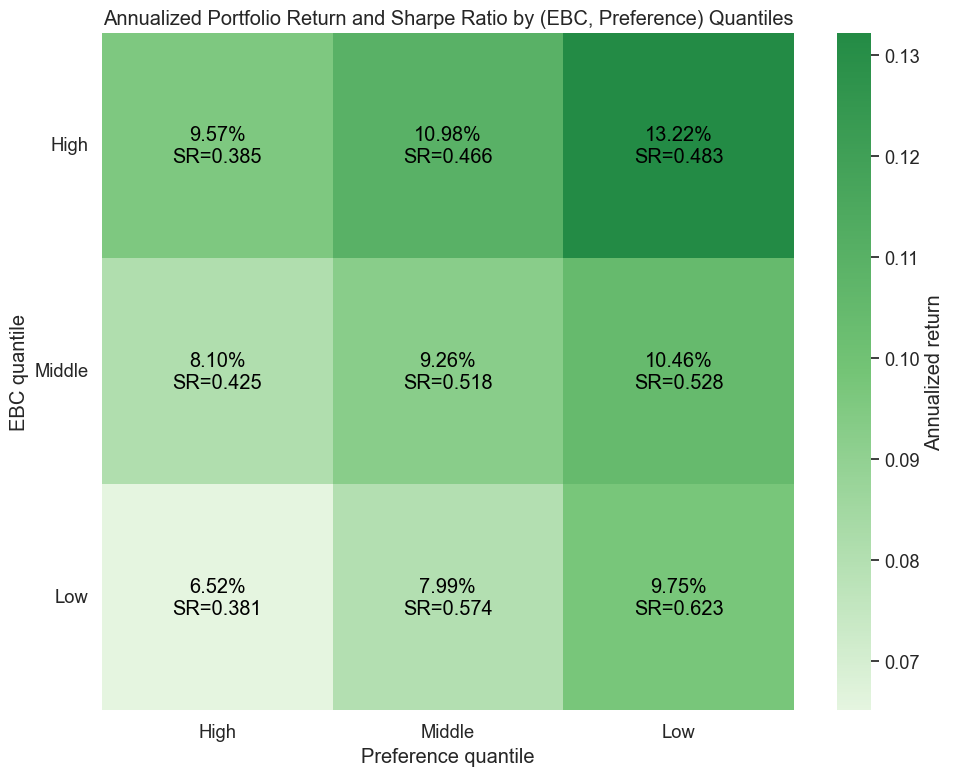

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Ensure consistent index/column labels between the two grids
mean_grid_annual.index = [f"Q{i}" for i in range(1, mean_grid_annual.shape[0] + 1)]
mean_grid_annual.columns = [f"Q{j}" for j in range(1, mean_grid_annual.shape[1] + 1)]

sharpe_matrix_EW.index = [f"Q{i}" for i in range(1, sharpe_matrix_EW.shape[0] + 1)]
sharpe_matrix_EW.columns = [f"Q{j}" for j in range(1, sharpe_matrix_EW.shape[1] + 1)]

# Create annotation text combining returns and Sharpe ratios
annot_text = pd.DataFrame(index=mean_grid_annual.index, columns=mean_grid_annual.columns)

for i in mean_grid_annual.index:
    for j in mean_grid_annual.columns:
        ret = mean_grid_annual.loc[i, j]
        sharpe = sharpe_matrix_EW.loc[i, j]
        if pd.notna(ret) and pd.notna(sharpe):
            annot_text.loc[i, j] = f"{ret:.2%}\nSR={sharpe:.3f}"
        elif pd.notna(ret):
            annot_text.loc[i, j] = f"{ret:.2%}"
        else:
            annot_text.loc[i, j] = ""

# Plot
plt.figure(figsize=(10, 8))
#colors = ["#d9f0d3", "#74c476", "#006d2c"]  # light mint → medium green → dark forest
colors = ["#e5f5e0", "#74c476", "#238b45"]


custom_cmap = LinearSegmentedColormap.from_list("poster_green_gradient", colors)
sns.heatmap(
    mean_grid_annual,
    annot=annot_text,
    fmt="",
    cmap=custom_cmap,
    cbar_kws={'label': 'Annualized return'},
    annot_kws={"color": "black"}
)
plt.title("Annualized Portfolio Return and Sharpe Ratio by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'])
plt.yticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'], rotation=0)
plt.tight_layout()
plt.show()

